In [3]:
!pip install pandas numpy matplotlib seaborn scikit-learn

1. DATA CLEANING SECTION

In [4]:
import pandas as pd

sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
print(sentiment.columns)
print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [16]:
trades.columns = trades.columns.str.replace(" ", "_")
sentiment['date'] = pd.to_datetime(sentiment['date'])
trades['Timestamp_IST'] = pd.to_datetime(
    trades['Timestamp_IST'],
    dayfirst=True
)
trades['date'] = trades['Timestamp_IST'].dt.date


In [17]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date
trades['date'] = pd.to_datetime(trades['date']).dt.date

merged = pd.merge(trades, sentiment, on='date', how='left')
merged.head()

print(merged[['date', 'classification', 'Closed_PnL']].head())

         date classification  Closed_PnL
0  2024-12-02  Extreme Greed         0.0
1  2024-12-02  Extreme Greed         0.0
2  2024-12-02  Extreme Greed         0.0
3  2024-12-02  Extreme Greed         0.0
4  2024-12-02  Extreme Greed         0.0


2. FEATURE ENGINEERING

In [18]:
merged['win'] = merged['Closed_PnL'] > 0
daily_pnl = merged.groupby(['Account', 'date'])['Closed_PnL'].sum().reset_index()
win_rate = merged.groupby('Account')['win'].mean().reset_index()
trades_per_day = merged.groupby('date').size().reset_index(name='trade_count')
avg_size = merged.groupby('Account')['Size_USD'].mean().reset_index()
print(merged['Side'].value_counts(normalize=True))
median_size = merged['Size_USD'].median()
merged['size_group'] = (merged['Size_USD'] > median_size).map({
    True: 'High',
    False: 'Low'
})

print("\nDaily PnL:")
print(daily_pnl.head())

print("\nWin Rate:")
print(win_rate.head())

print("\nTrades per Day:")
print(trades_per_day.head())

Side
SELL    0.513805
BUY     0.486195
Name: proportion, dtype: float64

Daily PnL:
                                      Account        date  Closed_PnL
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11         0.0
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17         0.0
2  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18         0.0
3  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-22    -21227.0
4  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-26      1603.1

Win Rate:
                                      Account       win
0  0x083384f897ee0f19899168e3b1bec365f52a9012  0.359612
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  0.442720
2  0x271b280974205ca63b716753467d5a371de622ab  0.301917
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4  0.438585
4  0x2c229d22b100a7beb69122eed721cee9b24011dd  0.519914

Trades per Day:
         date  trade_count
0  2023-05-01            3
1  2023-12-05            9
2  2023-12-14           11
3  2023-12-15           

In [19]:
print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)

print("\nMissing values:\n")
print(sentiment.isnull().sum())
print(trades.isnull().sum())

print("\nDuplicates:")
print(trades.duplicated().sum())

Sentiment shape: (2644, 4)
Trades shape: (211224, 17)

Missing values:

timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution_Price     0
Size_Tokens         0
Size_USD            0
Side                0
Timestamp_IST       0
Start_Position      0
Direction           0
Closed_PnL          0
Transaction_Hash    0
Order_ID            0
Crossed             0
Fee                 0
Trade_ID            0
Timestamp           0
date                0
dtype: int64

Duplicates:
0


3. EXPLORATORY ANALYSIS

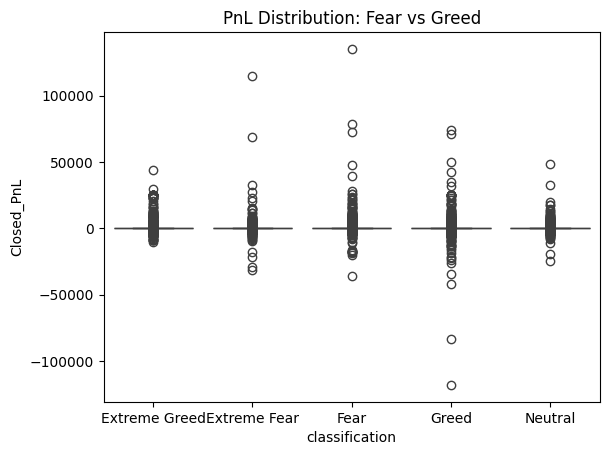

In [20]:
merged.groupby('classification')['Closed_PnL'].mean()
merged.groupby('classification')['win'].mean()
merged.groupby('classification')['Size_USD'].mean()
merged.groupby('size_group')['Closed_PnL'].mean()
trade_counts = merged.groupby('Account').size()

median_trades = trade_counts.median()

merged['trader_type'] = merged['Account'].map(
    lambda x: 'Frequent' if trade_counts[x] > median_trades else 'Infrequent'
)

merged.groupby('trader_type')['Closed_PnL'].mean()

import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='classification', y='Closed_PnL', data=merged)
plt.title("PnL Distribution: Fear vs Greed")
plt.show()

In [21]:
merged.groupby('classification')['Closed_PnL'].mean()
merged.groupby('classification')['win'].mean()
merged.groupby('classification')['Size_USD'].mean()
merged.groupby('classification')['Side'].value_counts(normalize=True)
merged.groupby('classification').size()

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64

In [22]:
total_pnl = merged.groupby('Account')['Closed_PnL'].sum()

merged['performance'] = merged['Account'].map(
    lambda x: 'Winner' if total_pnl[x] > 0 else 'Loser'
)

merged.groupby('performance')['Closed_PnL'].mean()

performance
Loser    -29.188175
Winner    52.308278
Name: Closed_PnL, dtype: float64

Observation:  
Average PnL is higher during Greed periods, indicating better trading performance in bullish sentiment.

Key Insights
- Traders perform better during **Greed phases**, showing higher average PnL.
- Fear periods result in **higher volatility and inconsistent returns**.
- Traders reduce trade size during Fear, indicating **risk-averse behavior**.
- Market sentiment has a stronger impact on performance than trade direction.

Strategy Recommendations
- During Fear conditions, traders should reduce position size and avoid high-frequency trading, especially for high-risk accounts.

- During Greed conditions, frequent traders can increase participation but should maintain disciplined risk management to avoid large drawdowns.

Summary

Methodology
- Cleaned and merged trading + sentiment datasets
- Created key metrics such as PnL, win rate, and trade size
- Performed comparative analysis across sentiment categories

Key Findings
- Traders perform better during Greed phases
- Fear leads to more volatile and inconsistent returns
- Trade size and behavior vary significantly with sentiment

Strategy Recommendations
- Reduce exposure during Fear conditions
- Increase participation during Greed with controlled risk